In [1]:
import os
import sys

os.chdir("/Users/karima/Ironhack-challenges/fake-news-nlp-classification")
sys.path.append(os.getcwd())

print(os.getcwd())

/Users/karima/Ironhack-challenges/fake-news-nlp-classification


In [2]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

from src.data_loader import load_data, prepare_features_and_labels, split_data
from src.preprocessing import preprocess_data
from src.feature_extraction import create_bow_features
from src.evaluator import evaluate_model, save_confusion_matrix, save_metrics_plot
from src.experiment_tracker import save_experiment_result
from src.model_manager import save_model, save_vectorizer
from src.config import MODELS_DIR

In [3]:
# Class constants
MODEL_ID = "exp_02"
MODEL_NAME = "Naive Bayes + Bag of Words"
FEATURES = "Bag of Words"
PREPROCESSING = "Lowercase + HTML removal + stopword removal + lemmatization"
ALGORITHM = "Multinomial Naive Bayes"
NOTES = "Naive Bayes model using Bag of Words features."
MODEL_PATH = MODELS_DIR / "bow_naive_bayes.pkl"

In [4]:
# Load the dataset
data = load_data()

In [5]:
# Extract features X and labels y
X, y = prepare_features_and_labels(data)

In [6]:
# Split the data into 80% train and 20% test
X_train, X_test, y_train, y_test = split_data(X, y)

In [7]:
# data cleaning, tokenizationa and lemmatization
X_train_clean = preprocess_data(X_train)
X_test_clean = preprocess_data(X_test)

In [8]:
# # 5. Create Bag of Words features
X_train_bow, X_test_bow, bow_vectorizer = create_bow_features(
    X_train_clean,
    X_test_clean
)

In [9]:
# Train the model
model = MultinomialNB()
model.fit(X_train_bow, y_train)


,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[15954.,15999.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.69,-0.69]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 87293)","[[ 8., 8., 1.,..., 2., 2., 1.], [20., 2., 0.,..., 0., 0., 0.]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 87293)","[[-12.94,-12.94,-14.44,...,-14.04,-14.04,-14.44], [-12.12,-14.06,-15.16,...,-15.16,-15.16,-15.16]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,87293


In [10]:
# evaluate the model
metrics, predictions = evaluate_model(
    model,
    X_test_bow,
    y_test
)

              precision    recall  f1-score   support

           0       0.95      0.95      0.95      3989
           1       0.95      0.95      0.95      4000

    accuracy                           0.95      7989
   macro avg       0.95      0.95      0.95      7989
weighted avg       0.95      0.95      0.95      7989



In [11]:
# Save the model and the vectorizer
model_path = save_model(
    model,
    "bow_naive_bayer.pkl"
)

vectorizer_path = save_vectorizer(
    bow_vectorizer,
    "bow_naive_bayer_vectorizer.pkl"
)

Model saved to: /Users/karima/Ironhack-challenges/fake-news-nlp-classification/models/bow_naive_bayer.pkl
Vectorizer saved to: /Users/karima/Ironhack-challenges/fake-news-nlp-classification/models/bow_naive_bayer_vectorizer.pkl


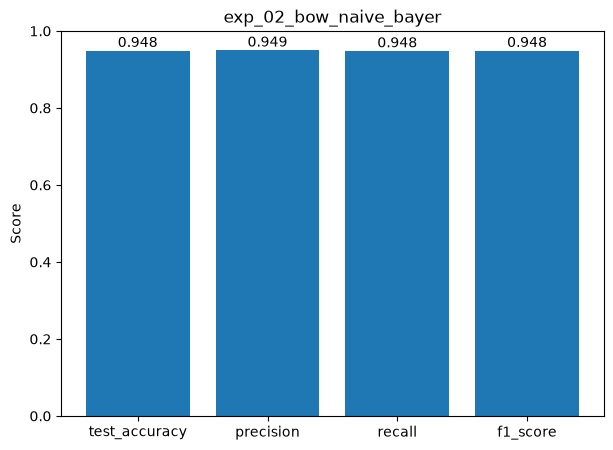

In [12]:
# Save and show metrics plot
metrics_plot_path = save_metrics_plot(
    metrics,
    "exp_02_bow_naive_bayer"
)

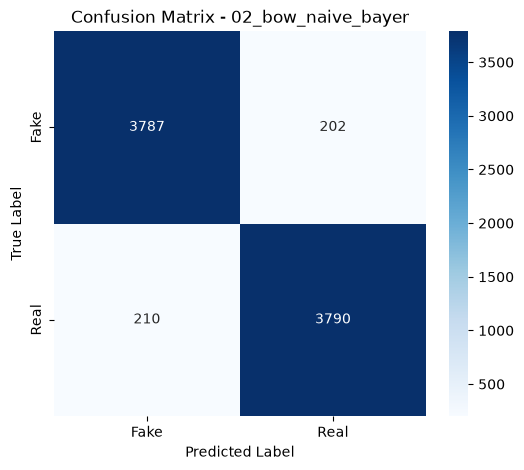

In [13]:
# Save and show confusion matrix
confusion_matrix_path = save_confusion_matrix(
    y_test,
    predictions,
    "02_bow_naive_bayer"
)

In [14]:
# Train accuracy
train_prediction = model.predict(X_train_bow)

train_accuracy = accuracy_score(
    y_train,
    train_prediction
)

In [15]:
# Save experiment result
experiment = {
    "model_id": MODEL_ID,
    "model_name": MODEL_NAME,
    "features": FEATURES,
    "preprocessing": PREPROCESSING,
    "algorithm": ALGORITHM,
    "train_accuracy": train_accuracy,
    "test_accuracy": metrics["test_accuracy"],
    "precision": metrics["precision"],
    "recall": metrics["recall"],
    "f1_score": metrics["f1_score"],
    "notes": NOTES,
    "model_path": MODEL_PATH,
}

tracking = save_experiment_result(**experiment)

tracking.tail()

,model_id,model_name,features,preprocessing,algorithm,train_accuracy,test_accuracy,precision,recall,f1_score,notes,model_path
0,exp_01,Baseline Logistic Regression + BoW,Bag of Words,Lowercase + HTML removal + stopword removal + ...,Logistic Regression,0.999969,0.994868,0.995494,0.99425,0.994872,Baseline Logigstic Bow Regresssioon model.,/Users/karima/Ironhack-challenges/fake-news-nl...
1,exp_01,Baseline Logistic Regression + BoW,Bag of Words,Lowercase + HTML removal + stopword removal + ...,Logistic Regression,0.999969,0.994868,0.995494,0.99425,0.994872,Baseline Logigstic Bow Regresssioon model.,/Users/karima/Ironhack-challenges/fake-news-nl...
2,exp_01,Baseline Logistic Regression + BoW,Bag of Words,Lowercase + HTML removal + stopword removal + ...,Logistic Regression,0.999969,0.994868,0.995494,0.99425,0.994872,Baseline Logigstic Bow Regresssioon model.,/Users/karima/Ironhack-challenges/fake-news-nl...
3,exp_02,Naive Bayes + Bag of Words,Bag of Words,Lowercase + HTML removal + stopword removal + ...,Multinomial Naive Bayes,0.959785,0.948429,0.949399,0.94750,0.948448,Naive Bayes model using Bag of Words features.,/Users/karima/Ironhack-challenges/fake-news-nl...
